In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/bitcoin_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

In [16]:
def save_plot(name):
    plt.savefig(
        f"../figures/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

# Moving Average Features

Moving averages smooth out short-term price fluctuations and help identify trends.

MA7:
Represents short-term market sentiment.

MA30:
Represents medium-term trend.

MA90:
Represents long-term market direction.

Interpretation:

- Price > MA → Bullish
- Price < MA → Bearish

Multiple moving averages help compare trend strength across different time horizons.

In [17]:
df["MA7"]=df["Close"].rolling(7).mean()
df["MA30"]=df["Close"].rolling(30).mean()
df["MA90"]=df["Close"].rolling(90).mean()

In [18]:
df[["Date","Close","MA7","MA30","MA90"]].tail(10)

,Date,Close,MA7,MA30,MA90
4270,2026-05-27,74344.703125,76304.610491,78381.463281,73576.935938
4271,2026-05-28,73536.554688,75732.808036,78287.659375,73661.988802
4272,2026-05-29,73372.523438,75430.562500,78207.539062,73732.840625
4273,2026-05-30,73754.835938,75013.629464,78122.556250,73821.915451
4274,2026-05-31,73579.687500,74527.709821,77969.245833,73875.291406
4275,2026-06-01,71319.773438,73676.258929,77724.663281,73908.915017
4276,2026-06-02,66703.656250,72373.104911,77330.177604,73842.171441
4277,2026-06-03,64014.367188,70897.342634,76803.059635,73766.318576
4278,2026-06-04,63801.574219,69506.631138,76232.210286,73718.152821
4279,2026-06-05,60922.667969,67728.080357,75548.714844,73647.598090


In [19]:
df["Price_vs_MA30"]=((df["Close"]-df["MA30"])/df["MA30"])*100

In [20]:
df["Price_vs_MA30"].tail(40)

4240     6.241192
4241     4.349516
4242     3.137429
4243     3.477425
4244     5.537842
4245     5.624101
4246     4.919164
4247     6.049980
4248     6.944481
4249     7.013427
4250     4.780083
4251     4.597748
4252     4.815288
4253     6.309557
4254     5.383726
4255     3.338979
4256     1.589220
4257     3.558794
4258     0.838860
4259    -0.478706
4260    -1.385666
4261    -2.041923
4262    -2.420515
4263    -1.587934
4264    -1.533989
4265    -4.028149
4266    -2.455485
4267    -2.044255
4268    -1.650183
4269    -3.384793
4270    -5.150146
4271    -6.068779
4272    -6.182288
4273    -5.590857
4274    -5.629859
4275    -8.240486
4276   -13.741752
4277   -16.651280
4278   -16.306278
4279   -19.359756
Name: Price_vs_MA30, dtype: float64

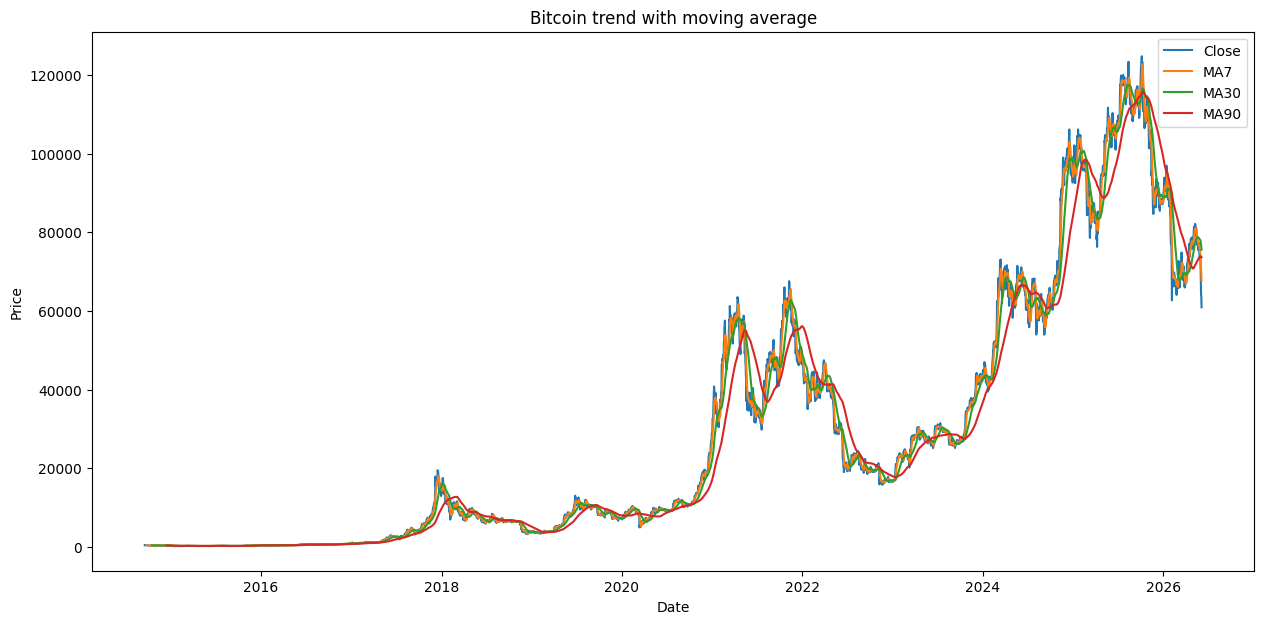

In [21]:
plt.figure(figsize=(15,7))
plt.plot(df["Date"],df["Close"],label="Close")
plt.plot(df["Date"],df["MA7"],label="MA7")
plt.plot(df["Date"],df["MA30"],label="MA30")
plt.plot(df["Date"],df["MA90"],label="MA90")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.title("Bitcoin trend with moving average")
save_plot("trend_on_MA")
plt.show()

In [23]:
df["MA7_vs_MA30_ratio"]=df["MA7"]/df["MA30"]
df["Close_vs_MA30_ratio"]=df["Close"]/df["MA30"]
df["Close_vs_MA30_ratio"].tail(10)

4270    0.948499
4271    0.939312
4272    0.938177
4273    0.944091
4274    0.943701
4275    0.917595
4276    0.862582
4277    0.833487
4278    0.836937
4279    0.806402
Name: Close_vs_MA30_ratio, dtype: float64

In [24]:
df["Delta"]=df["Close"].diff()
df["Delta"].head(20)

0           NaN
1    -32.894012
2    -29.644012
3     14.108002
4    -10.082977
5      3.330994
6     33.638977
7    -12.585999
8    -11.630981
9     -7.149017
10    -4.904999
11   -22.338989
12    -1.713989
13    11.476990
14    -3.329010
15    -8.542999
16   -15.559998
17   -30.645996
18    -8.355988
19     9.569000
Name: Delta, dtype: float64

In [25]:
df["Gain"]=df["Delta"].clip(lower=0)
df["Loss"]=-df["Delta"].clip(upper=0)
df["Avg_gain"]=df["Gain"].rolling(14).mean()
df["Avg_loss"]=df["Loss"].rolling(14).mean()

In [26]:
df["RS"]=df["Avg_gain"]/df["Avg_loss"]
df["RSI"]=100-(100/(1+df["RS"]))
df[["Date","Close","RSI"]].tail(10)

,Date,Close,RSI
4270,2026-05-27,74344.703125,31.920080
4271,2026-05-28,73536.554688,20.355300
4272,2026-05-29,73372.523438,23.771660
4273,2026-05-30,73754.835938,28.756698
4274,2026-05-31,73579.687500,30.307003
4275,2026-06-01,71319.773438,25.627508
4276,2026-06-02,66703.656250,18.546871
4277,2026-06-03,64014.367188,12.561952
4278,2026-06-04,63801.574219,12.020615
4279,2026-06-05,60922.667969,11.494390


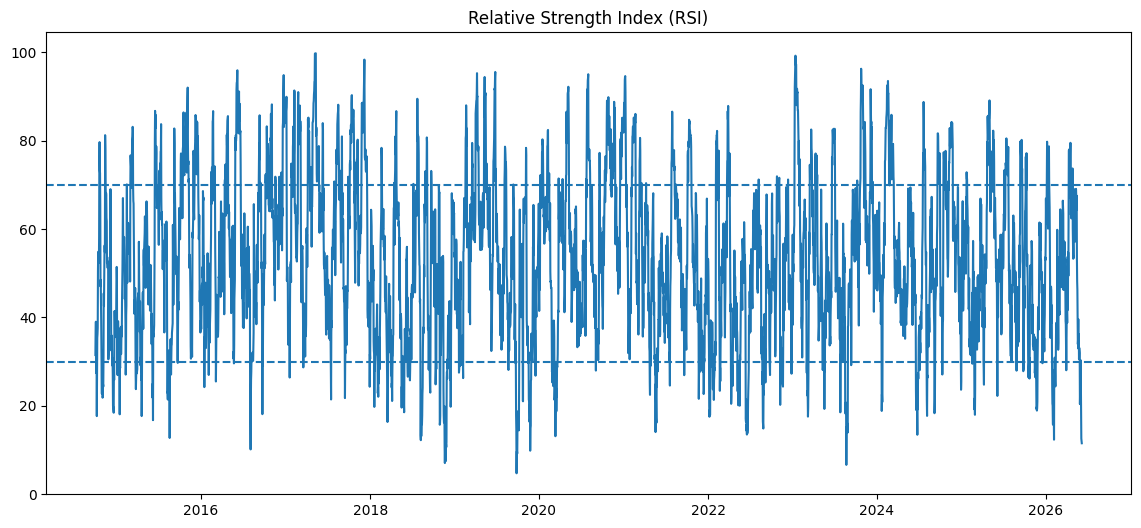

In [29]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["RSI"])

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("Relative Strength Index (RSI)")

save_plot("RSI")

plt.show()

In [27]:
df_ml = df.dropna().copy()
df_ml.shape

(4191, 20)

In [28]:
df_ml.to_csv(
    "../data/processed/bitcoin_features.csv",
    index=False
)

# Feature Engineering Summary

Features Created:

1. Daily Return
2. 30-Day Volatility
3. MA7
4. MA30
5. MA90
6. Close_vs_MA30_ratio
7. MA7_vs_MA30_ratio
8. RSI

Purpose:

These features capture:

- Momentum
- Trend Strength
- Relative Positioning
- Market Risk

The engineered dataset will be used for predictive modeling in the next notebook.